## Initial Premier League Data Analysis

This notebook contains exploratory data analysis results and visuals.

In [1]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "../data"
COLS = ["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR"]

In [ ]:
frames = []
for path in sorted(glob.glob(os.path.join(DATA_DIR, "*.csv"))):
    season = os.path.splitext(os.path.basename(path))[0]
    df = pd.read_csv(path, usecols=COLS)
    df["Season"] = season
    frames.append(df)

matches = pd.concat(frames, ignore_index=True)
matches["Date"] = pd.to_datetime(matches["Date"], dayfirst=True, errors="coerce")
matches.shape

# number of matches is 4180.

(4180, 7)

In [ ]:
matches.head()

# fthg: home goals, ftag: away goals, ftr: result (A: away, D: draw, H: home)

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,Season
0,2015-08-08,Bournemouth,Aston Villa,0,1,A,15-16
1,2015-08-08,Chelsea,Swansea,2,2,D,15-16
2,2015-08-08,Everton,Watford,2,2,D,15-16
3,2015-08-08,Leicester,Sunderland,4,2,H,15-16
4,2015-08-08,Man United,Tottenham,1,0,H,15-16


In [ ]:
matches.isna().sum()

# no nulls except 380 without dates

Date        380
HomeTeam      0
AwayTeam      0
FTHG          0
FTAG          0
FTR           0
Season        0
dtype: int64

In [ ]:
matches["FTR"].value_counts(normalize=True)

# percentage splits for H, A, D results

FTR
H    0.443301
A    0.319856
D    0.236842
Name: proportion, dtype: float64

In [ ]:
matches[["FTHG", "FTAG"]].describe()

# various stats for home goals versus away goals

,FTHG,FTAG
count,4180.000000,4180.000000
mean,1.549522,1.273206
std,1.308462,1.202414
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,9.000000,9.000000


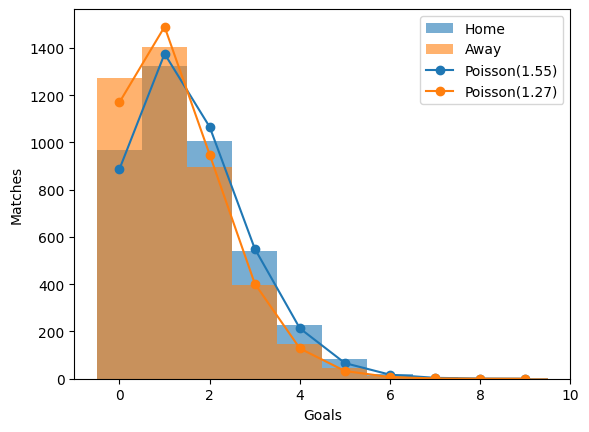

In [ ]:
max_goals = int(max(matches["FTHG"].max(), matches["FTAG"].max()))
bins = np.arange(0, max_goals + 2) - 0.5
k = np.arange(0, max_goals + 1)
n = len(matches)

def poisson_counts(avg, ks, n): # compute poisson dists based on means
    p = np.empty(len(ks))
    p[0] = np.exp(-avg)
    for i in range(1, len(ks)):
        p[i] = p[i - 1] * avg / i
    return n * p

home = matches["FTHG"].mean()
away = matches["FTAG"].mean()

fig, ax = plt.subplots()
ax.hist(matches["FTHG"], bins=bins, alpha=0.6, label="Home")
ax.hist(matches["FTAG"], bins=bins, alpha=0.6, label="Away")
ax.plot(k, poisson_counts(home, k, n), "o-", color="C0", label=f"Poisson({home:.2f})")
ax.plot(k, poisson_counts(away, k, n), "o-", color="C1", label=f"Poisson({away:.2f})")
ax.set_xlabel("Goals")
ax.set_ylabel("Matches")
ax.legend()
plt.show()

# notice that the data models poisson distribution 